# Notebook 03: Exploratory Data Analysis and Visualization

**Input**: `daily_features.csv`, `scanner_data_clean.csv`  
**Output**: Thesis-ready figures exported to `/figures/`

In [ ]:
# --- Colab Setup (run this cell first if using Google Colab) ---
import os, sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    if not os.path.exists('/content/cattle-anomaly-detection'):
        !git clone https://github.com/dimvsh/cattle-anomaly-detection.git /content/cattle-anomaly-detection
    os.chdir('/content/cattle-anomaly-detection/notebooks')
    !pip install -q -r /content/cattle-anomaly-detection/requirements.txt
    print("Colab setup complete.")
else:
    print("Running locally.")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os

# Style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (12, 6)

# Paths
PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED_DIR = os.path.join(PROJECT_DIR, 'data', 'processed')
FIGURES_DIR = os.path.join(PROJECT_DIR, 'figures')

# Load data
df_visits = pd.read_csv(os.path.join(PROCESSED_DIR, 'scanner_data_clean.csv'), parse_dates=['start_dt', 'end_dt'])
df_daily = pd.read_csv(os.path.join(PROCESSED_DIR, 'daily_features.csv'), parse_dates=['date'])
df_animals = pd.read_csv(os.path.join(PROCESSED_DIR, 'animals.csv'))

# Ensure tag_short is string everywhere
df_visits['tag_short'] = df_visits['tag_short'].astype(str)
df_daily['tag_short'] = df_daily['tag_short'].astype(str)
df_animals['tag_short'] = df_animals['tag_short'].astype(str)

# Identify sick animals
sick_tags = df_animals[df_animals['is_sick'] == 1]['tag_short'].tolist()
sick_with_data = [t for t in sick_tags if t in df_daily['tag_short'].values]

# Colors and labels for sick animals (used across multiple figures)
colors = {'1129': '#e74c3c', '1149': '#2980b9'}
labels = {'1129': 'Animal 1129 (pneumonia)', '1149': 'Animal 1149 (bloat)'}

print(f"Loaded: {len(df_visits):,} visits, {len(df_daily)} daily records, {len(df_animals)} animals")
print(f"Sick animals in dataset: {sick_with_data}")

Loaded: 32,118 visits, 793 daily records, 34 animals
Sick animals in dataset: ['1129', '1149']


## Figure 1: Daily Drinking Duration Over Time (All Animals)

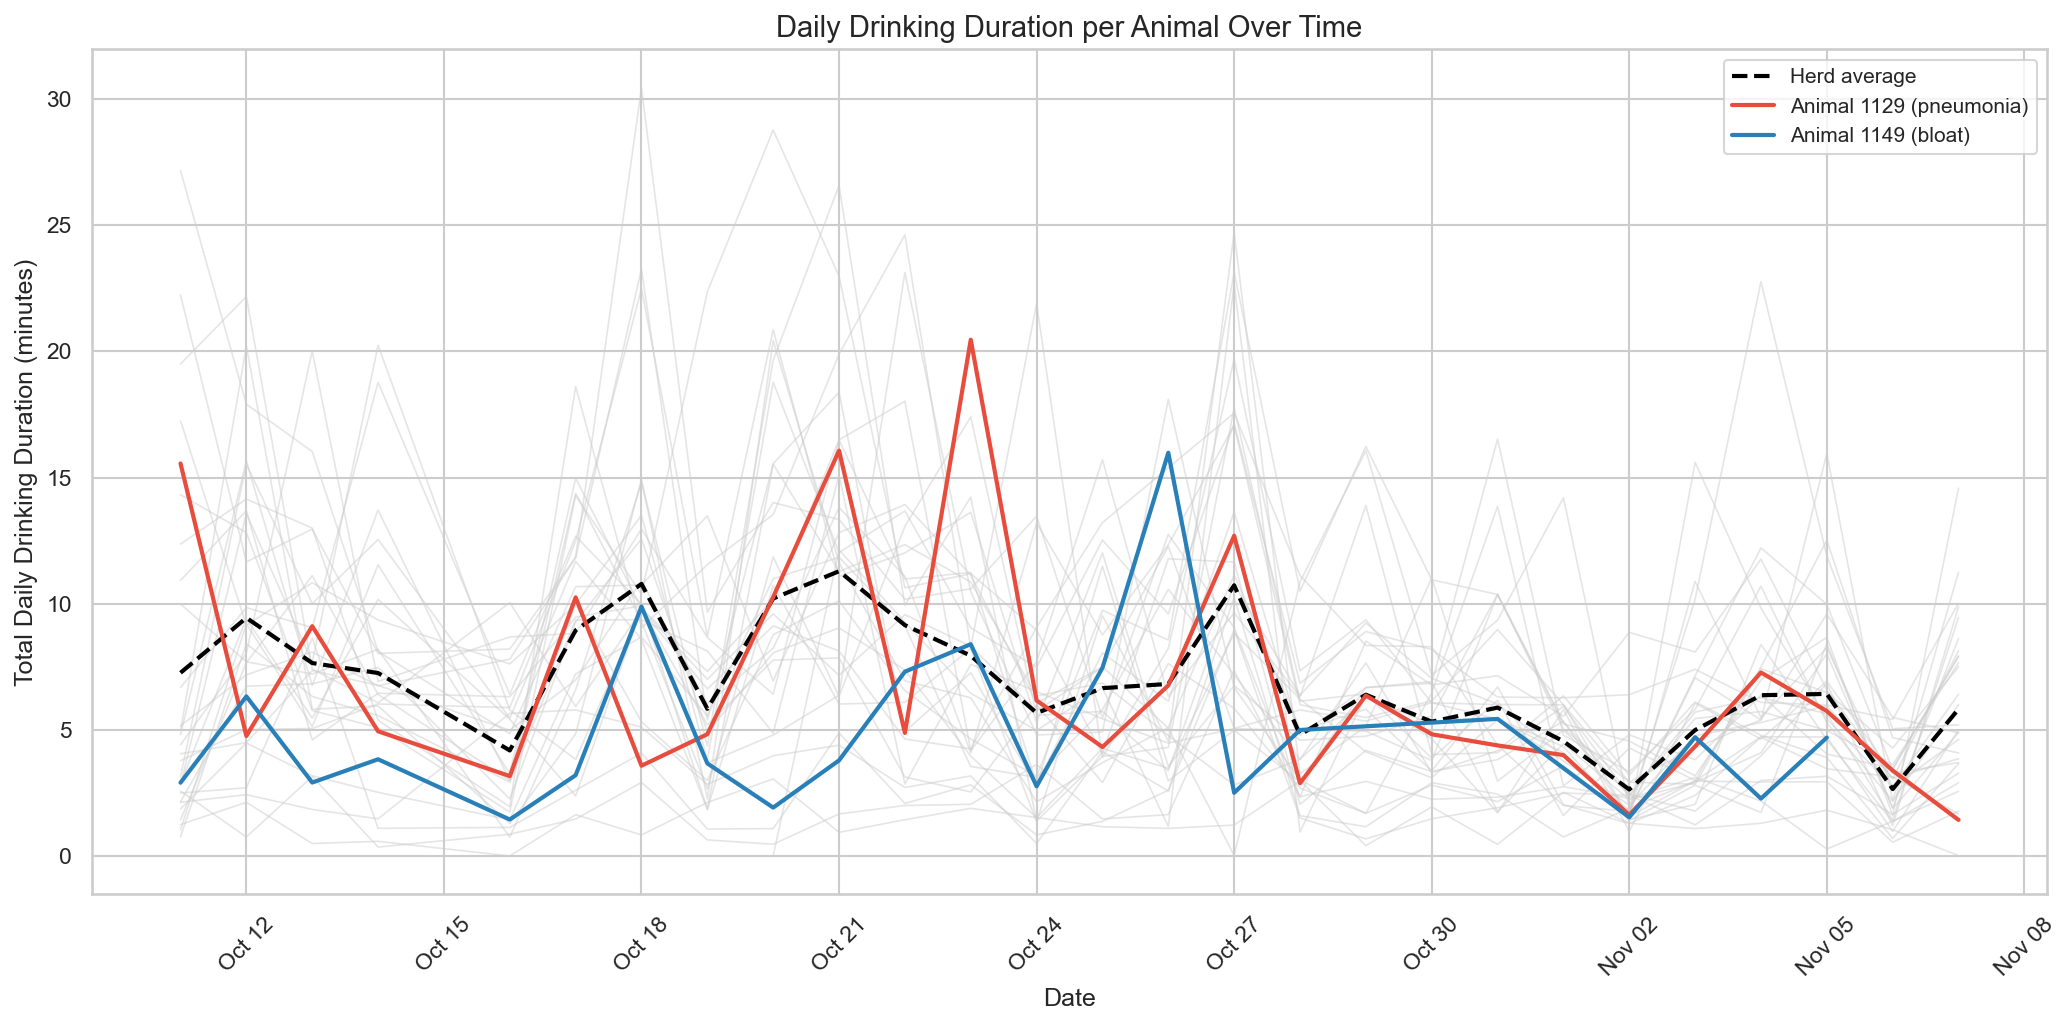

Saved: fig1_daily_duration_timeline.png


In [2]:
# Figure 1: Daily total drinking duration — all animals, sick highlighted
fig, ax = plt.subplots(figsize=(14, 7))

for tag in df_daily['tag_short'].unique():
    animal_data = df_daily[df_daily['tag_short'] == tag]
    if tag in sick_with_data:
        continue  # plot sick animals on top later
    ax.plot(animal_data['date'], animal_data['total_daily_duration'] / 60, 
            color='#cccccc', alpha=0.5, linewidth=0.8)

# Herd average
herd_avg = df_daily.groupby('date')['total_daily_duration'].mean() / 60
ax.plot(herd_avg.index, herd_avg.values, color='black', linewidth=2, label='Herd average', linestyle='--')

# Sick animals on top
colors = {'1129': '#e74c3c', '1149': '#2980b9'}
labels = {'1129': 'Animal 1129 (pneumonia)', '1149': 'Animal 1149 (bloat)'}
for tag in sick_with_data:
    animal_data = df_daily[df_daily['tag_short'] == tag]
    ax.plot(animal_data['date'], animal_data['total_daily_duration'] / 60, 
            color=colors.get(str(tag), 'red'), linewidth=2, label=labels.get(str(tag), f'Animal {tag}'))

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Daily Drinking Duration (minutes)', fontsize=12)
ax.set_title('Daily Drinking Duration per Animal Over Time', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig1_daily_duration_timeline.png'), bbox_inches='tight')
plt.show()
print("Saved: fig1_daily_duration_timeline.png")

## Figure 2: Visit Frequency Distribution

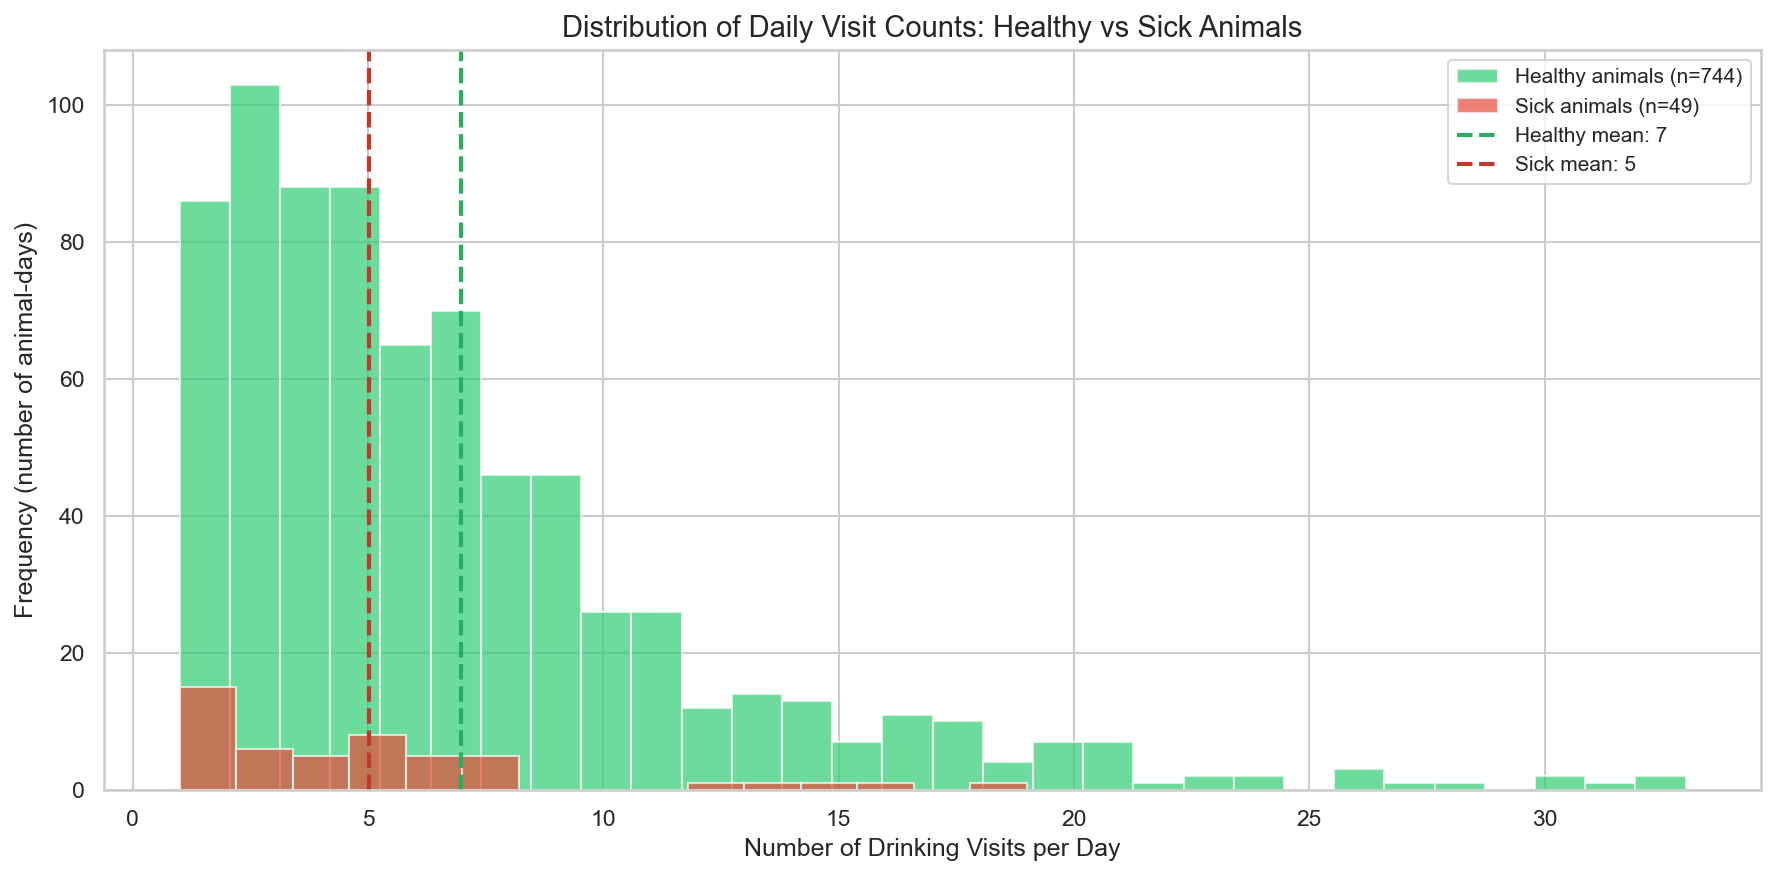

Saved: fig2_visit_count_distribution.png


In [3]:
# Figure 2: Distribution of daily visit counts — healthy vs sick
fig, ax = plt.subplots(figsize=(12, 6))

healthy = df_daily[df_daily['is_sick'] == 0]['visit_count']
sick = df_daily[df_daily['is_sick'] == 1]['visit_count']

ax.hist(healthy, bins=30, alpha=0.7, color='#2ecc71', label=f'Healthy animals (n={len(healthy)})', edgecolor='white')
ax.hist(sick, bins=15, alpha=0.7, color='#e74c3c', label=f'Sick animals (n={len(sick)})', edgecolor='white')

ax.axvline(healthy.mean(), color='#27ae60', linestyle='--', linewidth=2, label=f'Healthy mean: {healthy.mean():.0f}')
ax.axvline(sick.mean(), color='#c0392b', linestyle='--', linewidth=2, label=f'Sick mean: {sick.mean():.0f}')

ax.set_xlabel('Number of Drinking Visits per Day', fontsize=12)
ax.set_ylabel('Frequency (number of animal-days)', fontsize=12)
ax.set_title('Distribution of Daily Visit Counts: Healthy vs Sick Animals', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig2_visit_count_distribution.png'), bbox_inches='tight')
plt.show()
print("Saved: fig2_visit_count_distribution.png")

## Figure 3: Drinking Activity by Hour of Day

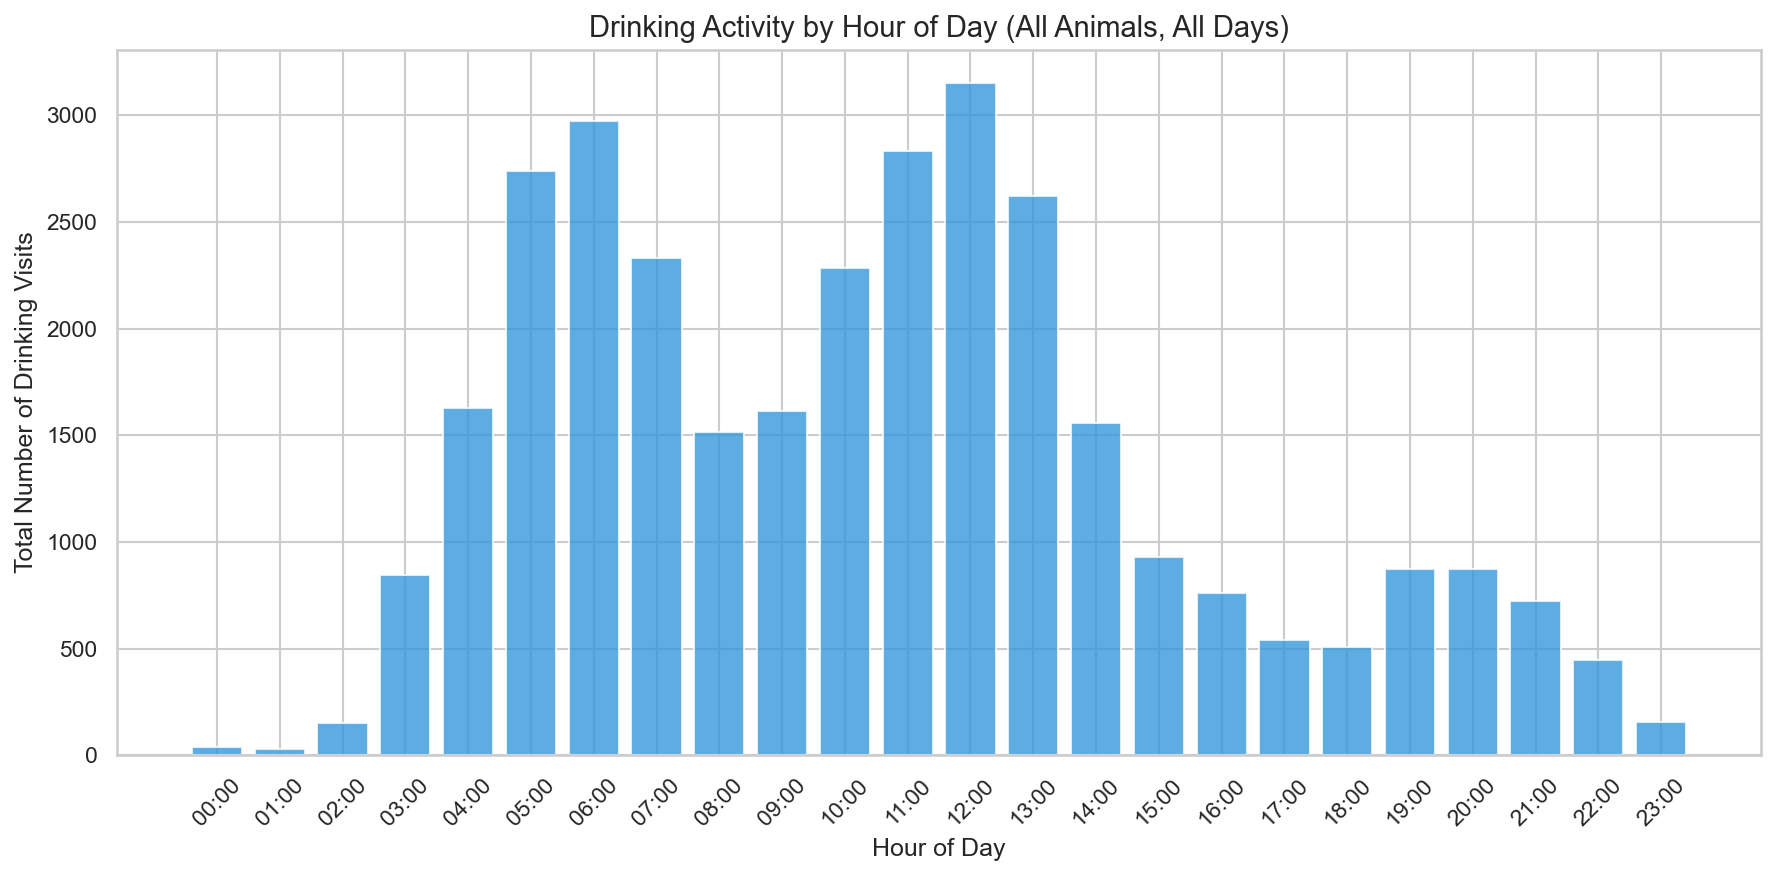

Saved: fig3_hourly_pattern.png


In [4]:
# Figure 3: When do animals drink? Hour-of-day pattern
df_visits['hour'] = df_visits['start_dt'].dt.hour

fig, ax = plt.subplots(figsize=(12, 6))

hourly_counts = df_visits.groupby('hour').size()
ax.bar(hourly_counts.index, hourly_counts.values, color='#3498db', edgecolor='white', alpha=0.8)

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Total Number of Drinking Visits', fontsize=12)
ax.set_title('Drinking Activity by Hour of Day (All Animals, All Days)', fontsize=14)
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig3_hourly_pattern.png'), bbox_inches='tight')
plt.show()
print("Saved: fig3_hourly_pattern.png")

## Figure 4: Heatmap — Animals x Days (Total Drinking Duration)

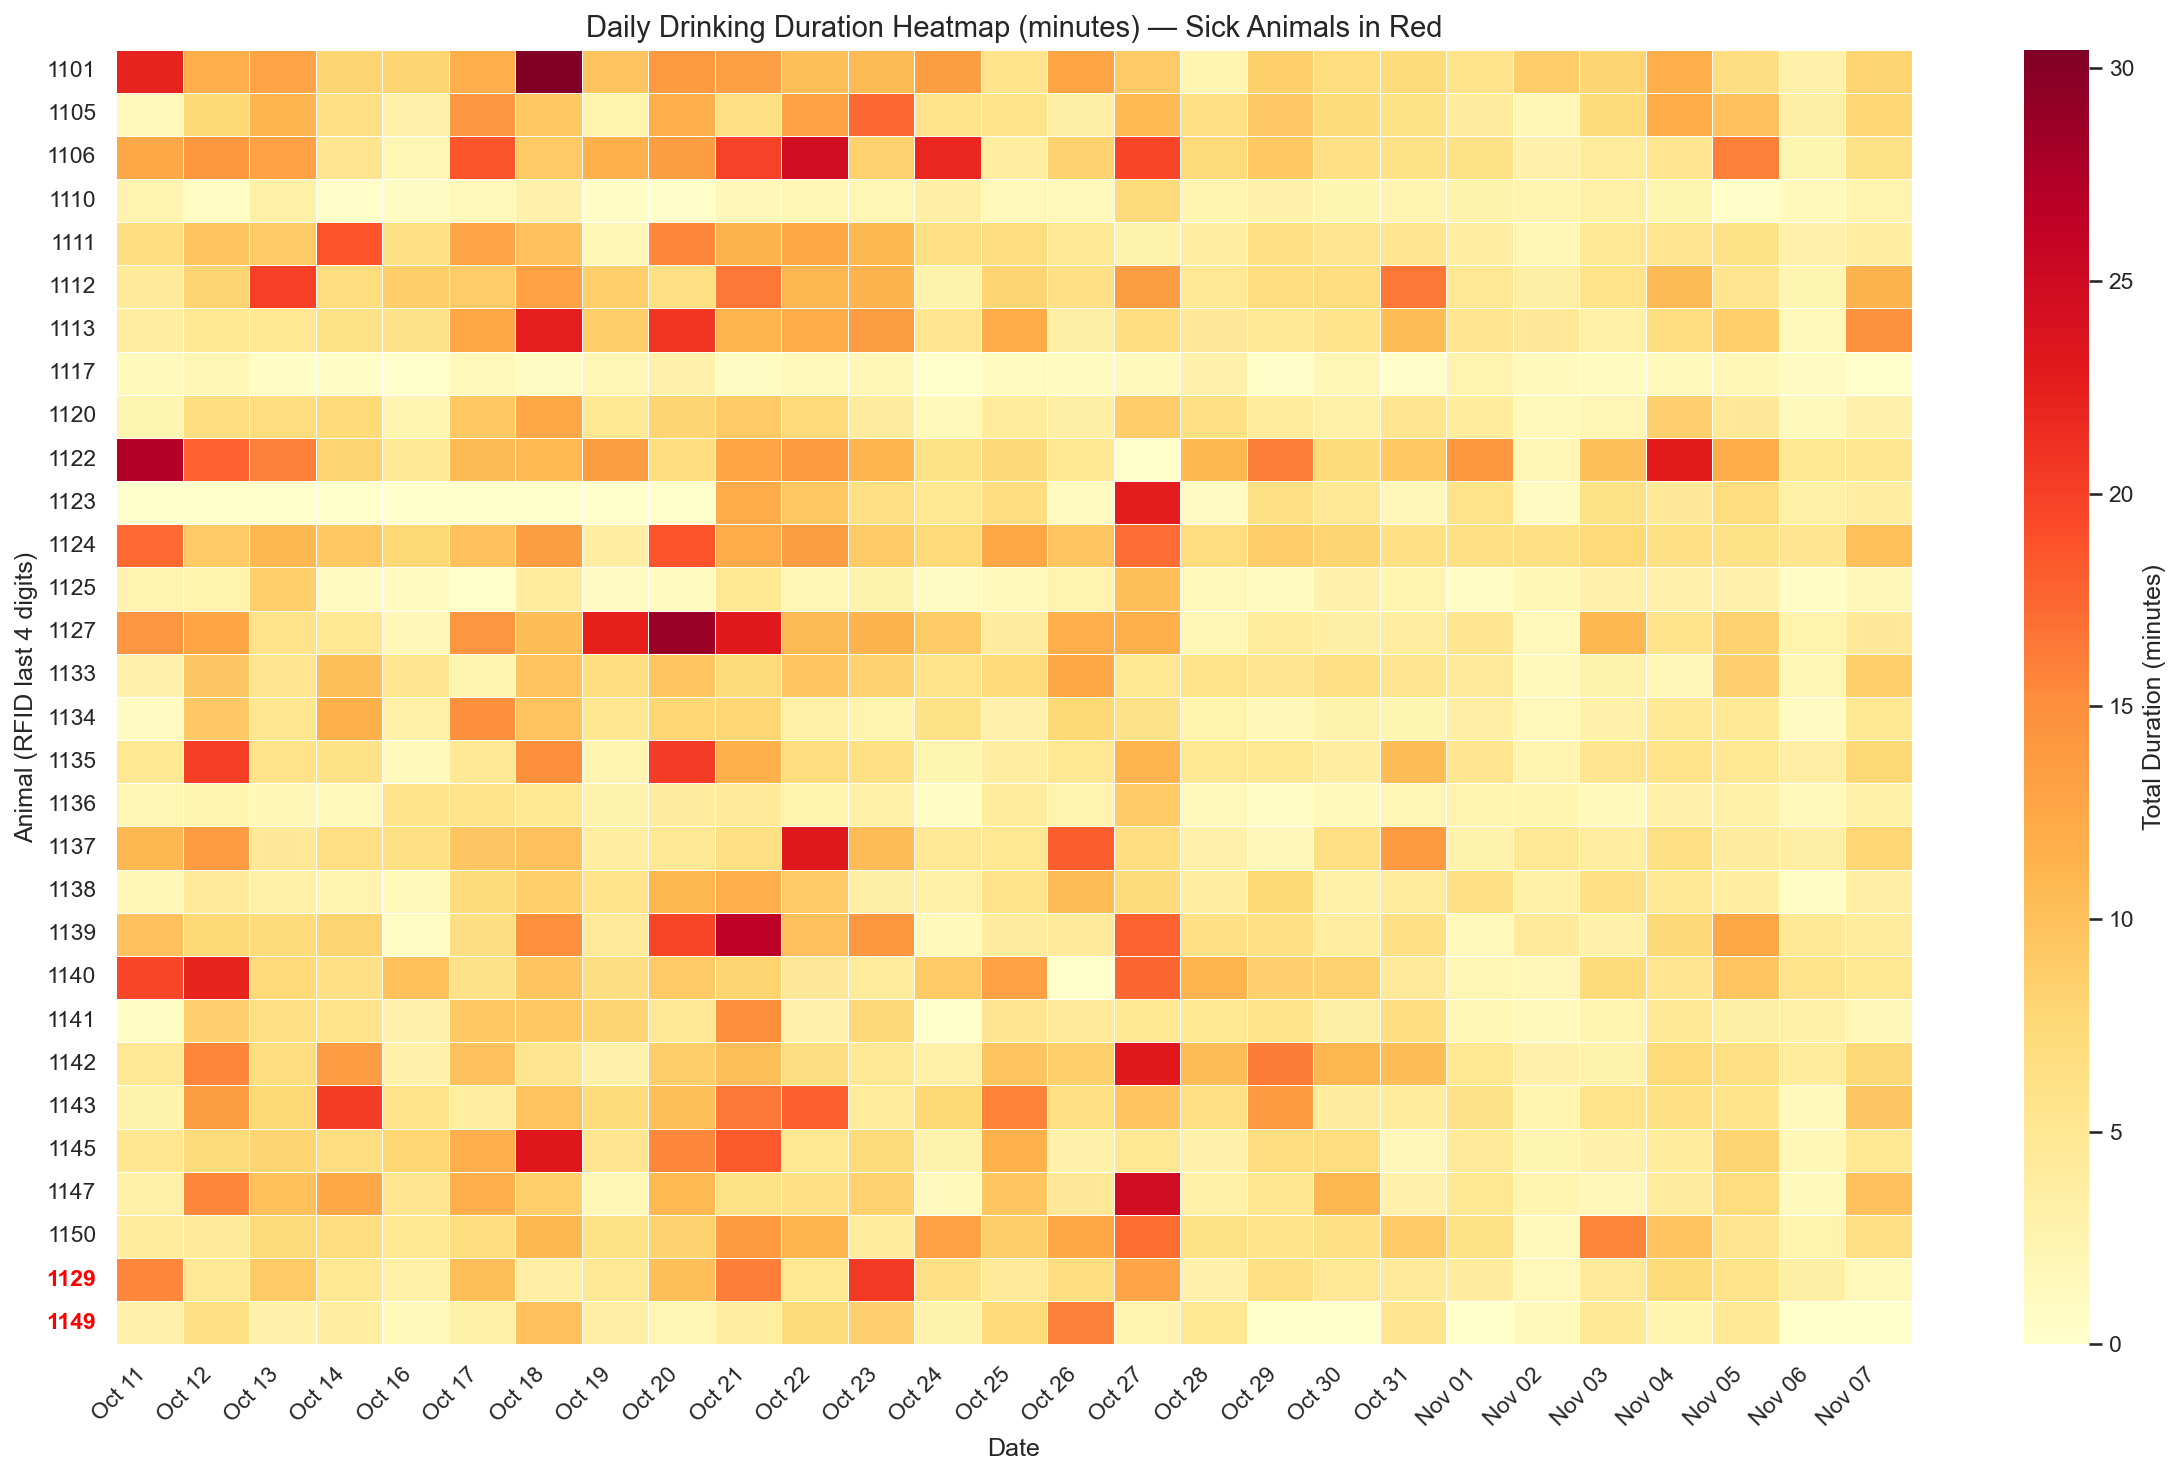

Saved: fig4_heatmap_duration.png


In [5]:
# Figure 4: Heatmap of daily drinking duration (animals x days)
pivot = df_daily.pivot_table(index='tag_short', columns='date', values='total_daily_duration', fill_value=0)
pivot = pivot / 60  # convert to minutes

# Sort animals: sick ones at the bottom for visibility
sick_mask = pivot.index.isin([str(t) for t in sick_with_data])
order = list(pivot.index[~sick_mask]) + list(pivot.index[sick_mask])
pivot = pivot.loc[order]

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Total Duration (minutes)'},
            xticklabels=[d.strftime('%b %d') for d in pivot.columns],
            linewidths=0.3, linecolor='white')

# Mark sick animals on y-axis
ytick_labels = ax.get_yticklabels()
for label in ytick_labels:
    if label.get_text() in [str(t) for t in sick_with_data]:
        label.set_color('red')
        label.set_fontweight('bold')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Animal (RFID last 4 digits)', fontsize=12)
ax.set_title('Daily Drinking Duration Heatmap (minutes) — Sick Animals in Red', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig4_heatmap_duration.png'), bbox_inches='tight')
plt.show()
print("Saved: fig4_heatmap_duration.png")

## Figure 5: Sick Animals vs Herd — All 4 Metrics Comparison

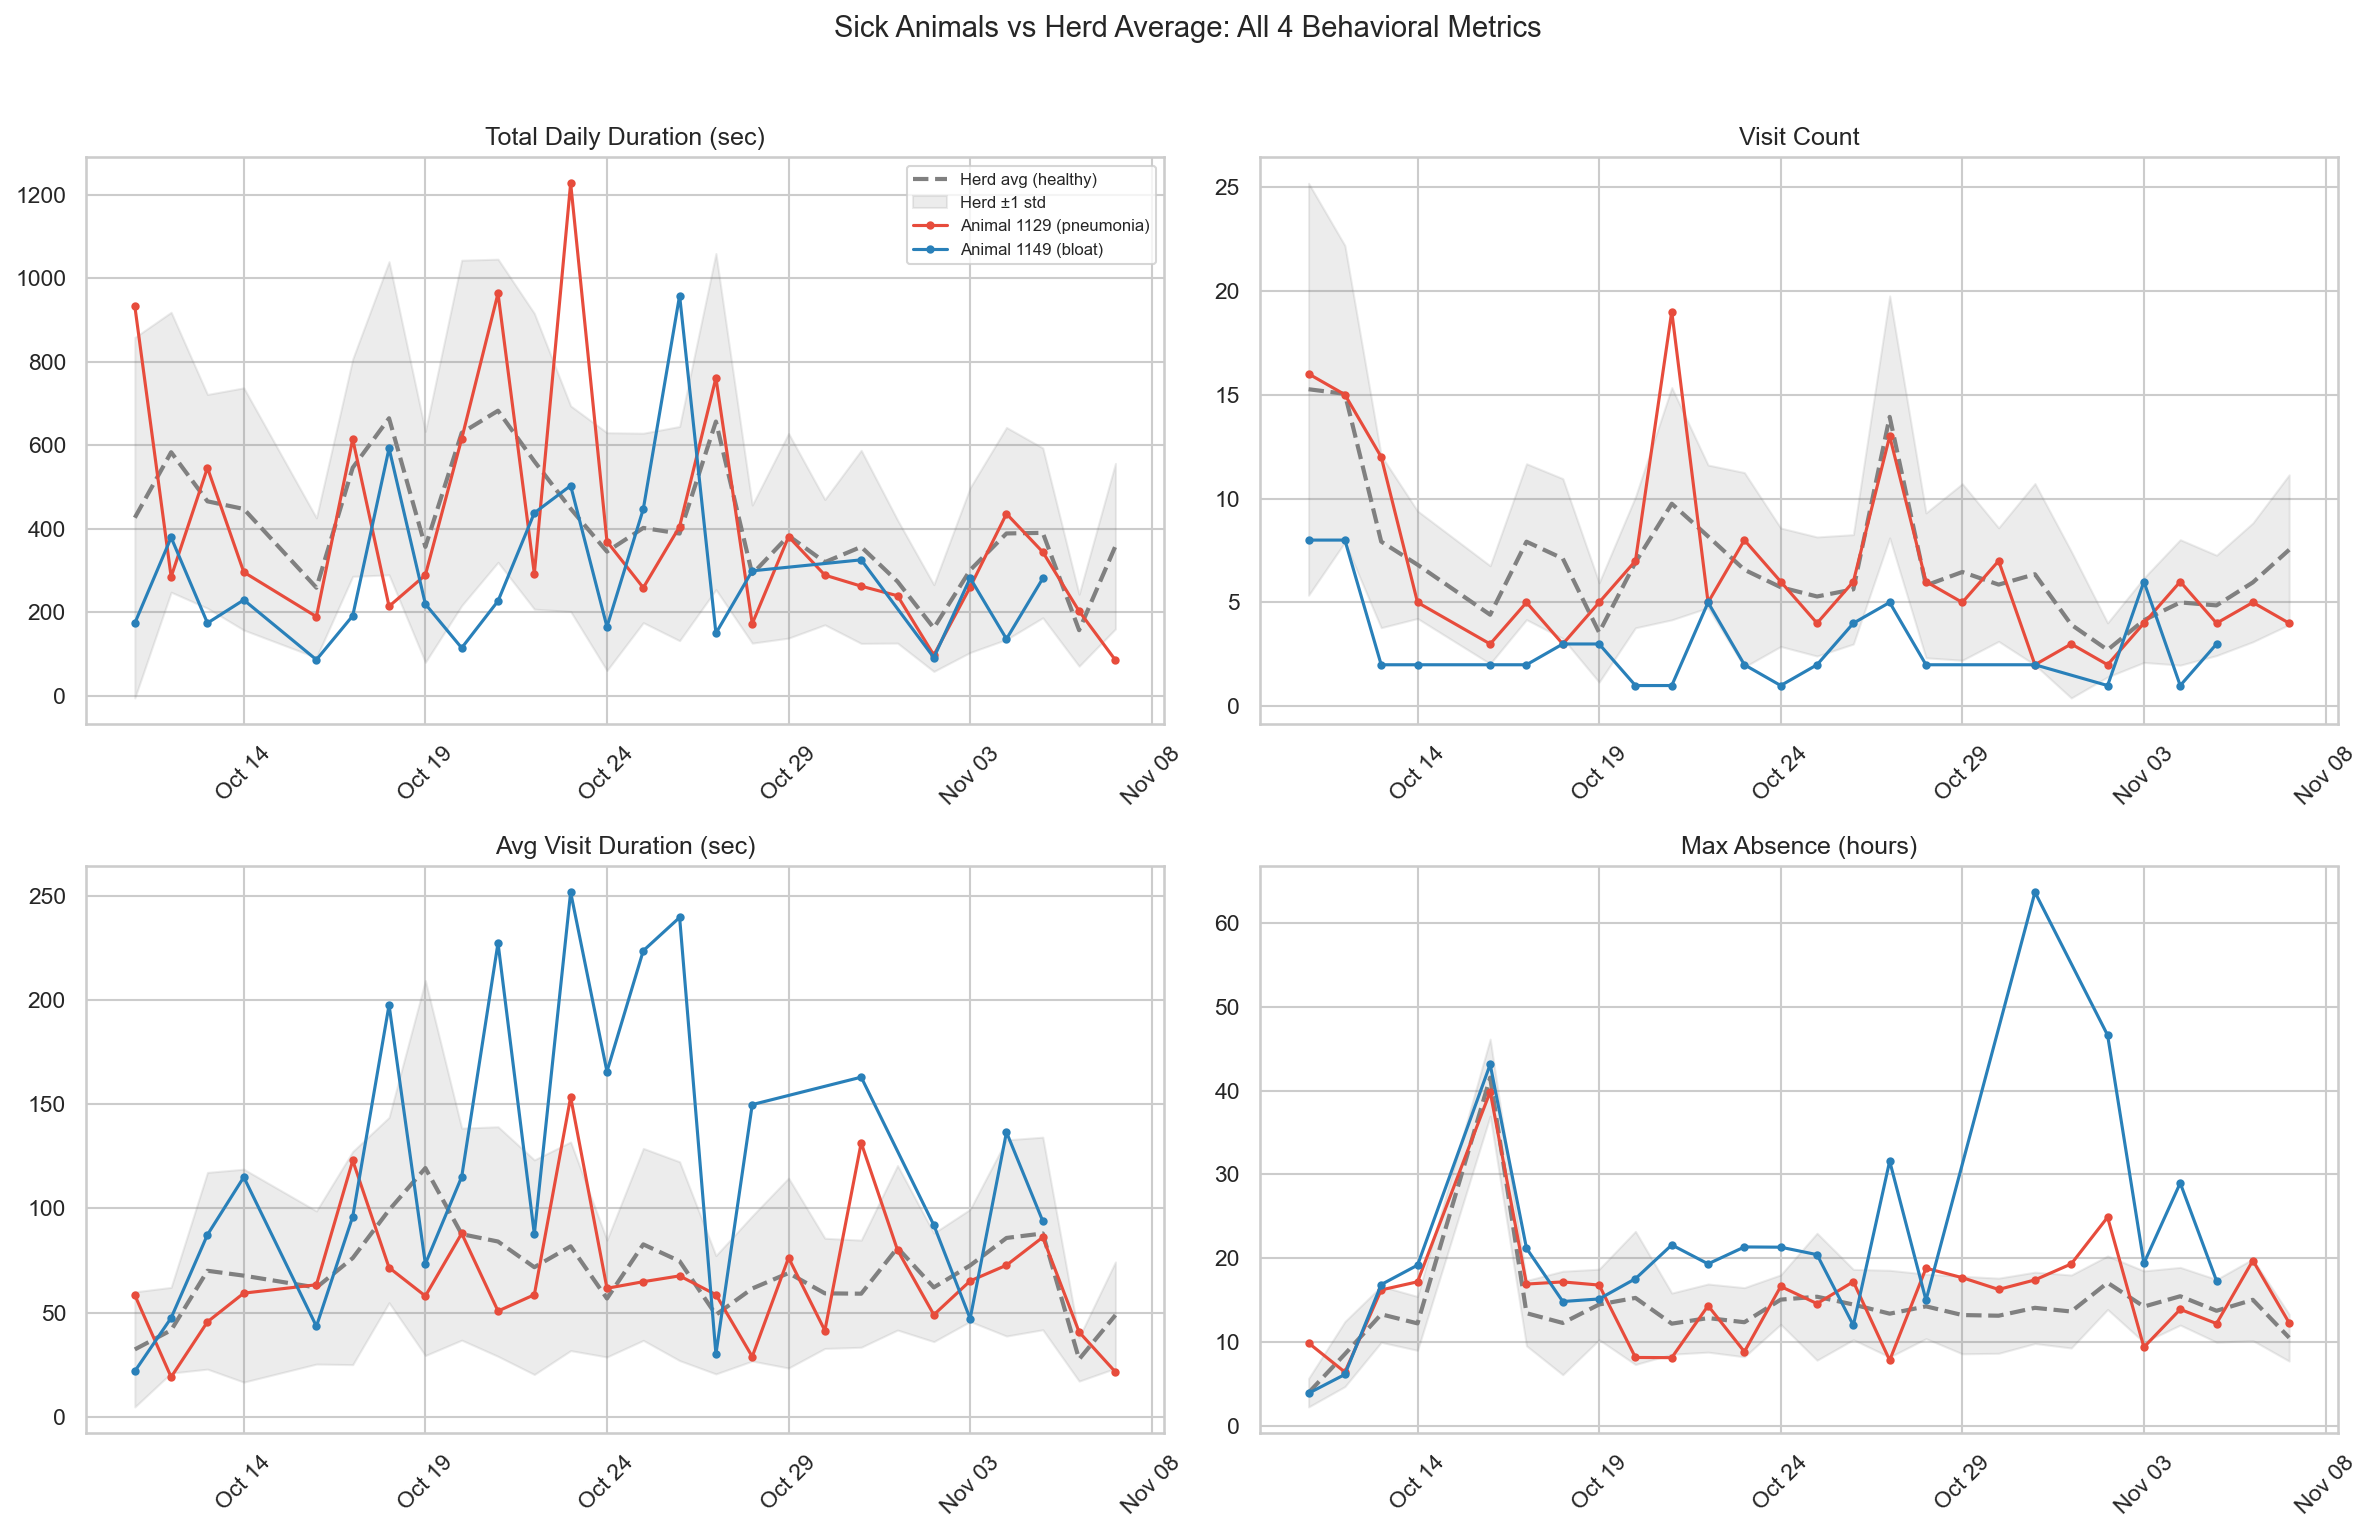

Saved: fig5_sick_vs_herd_metrics.png


In [6]:
# Figure 5: 2x2 panel — each metric over time, sick vs herd average
feature_cols = ['total_daily_duration', 'visit_count', 'avg_visit_duration', 'max_absence_hours']
feature_labels = ['Total Daily Duration (sec)', 'Visit Count', 'Avg Visit Duration (sec)', 'Max Absence (hours)']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(feature_cols, feature_labels)):
    ax = axes[i]
    
    # Herd average (excluding sick)
    herd = df_daily[df_daily['is_sick'] == 0].groupby('date')[col].mean()
    ax.plot(herd.index, herd.values, color='gray', linewidth=2, label='Herd avg (healthy)', linestyle='--')
    
    # Herd std band
    herd_std = df_daily[df_daily['is_sick'] == 0].groupby('date')[col].std()
    ax.fill_between(herd.index, herd.values - herd_std.values, herd.values + herd_std.values,
                    color='gray', alpha=0.15, label='Herd ±1 std')
    
    # Sick animals
    for tag in sick_with_data:
        animal = df_daily[df_daily['tag_short'] == tag]
        color = colors.get(str(tag), 'red')
        lbl = labels.get(str(tag), f'Animal {tag}')
        ax.plot(animal['date'], animal[col], color=color, linewidth=1.5, label=lbl, marker='o', markersize=3)
    
    ax.set_title(label, fontsize=12)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    ax.tick_params(axis='x', rotation=45)
    if i == 0:
        ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Sick Animals vs Herd Average: All 4 Behavioral Metrics', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig5_sick_vs_herd_metrics.png'), bbox_inches='tight')
plt.show()
print("Saved: fig5_sick_vs_herd_metrics.png")

## Figure 6: Box Plots of All 4 Features

/var/folders/nr/5rl8fzss1r1f4jnxv295pyq80000gn/T/ipykernel_39190/203214962.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_daily, x='tag_short', y=col, order=animal_order,
/var/folders/nr/5rl8fzss1r1f4jnxv295pyq80000gn/T/ipykernel_39190/203214962.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_daily, x='tag_short', y=col, order=animal_order,


/var/folders/nr/5rl8fzss1r1f4jnxv295pyq80000gn/T/ipykernel_39190/203214962.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_daily, x='tag_short', y=col, order=animal_order,
/var/folders/nr/5rl8fzss1r1f4jnxv295pyq80000gn/T/ipykernel_39190/203214962.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_daily, x='tag_short', y=col, order=animal_order,


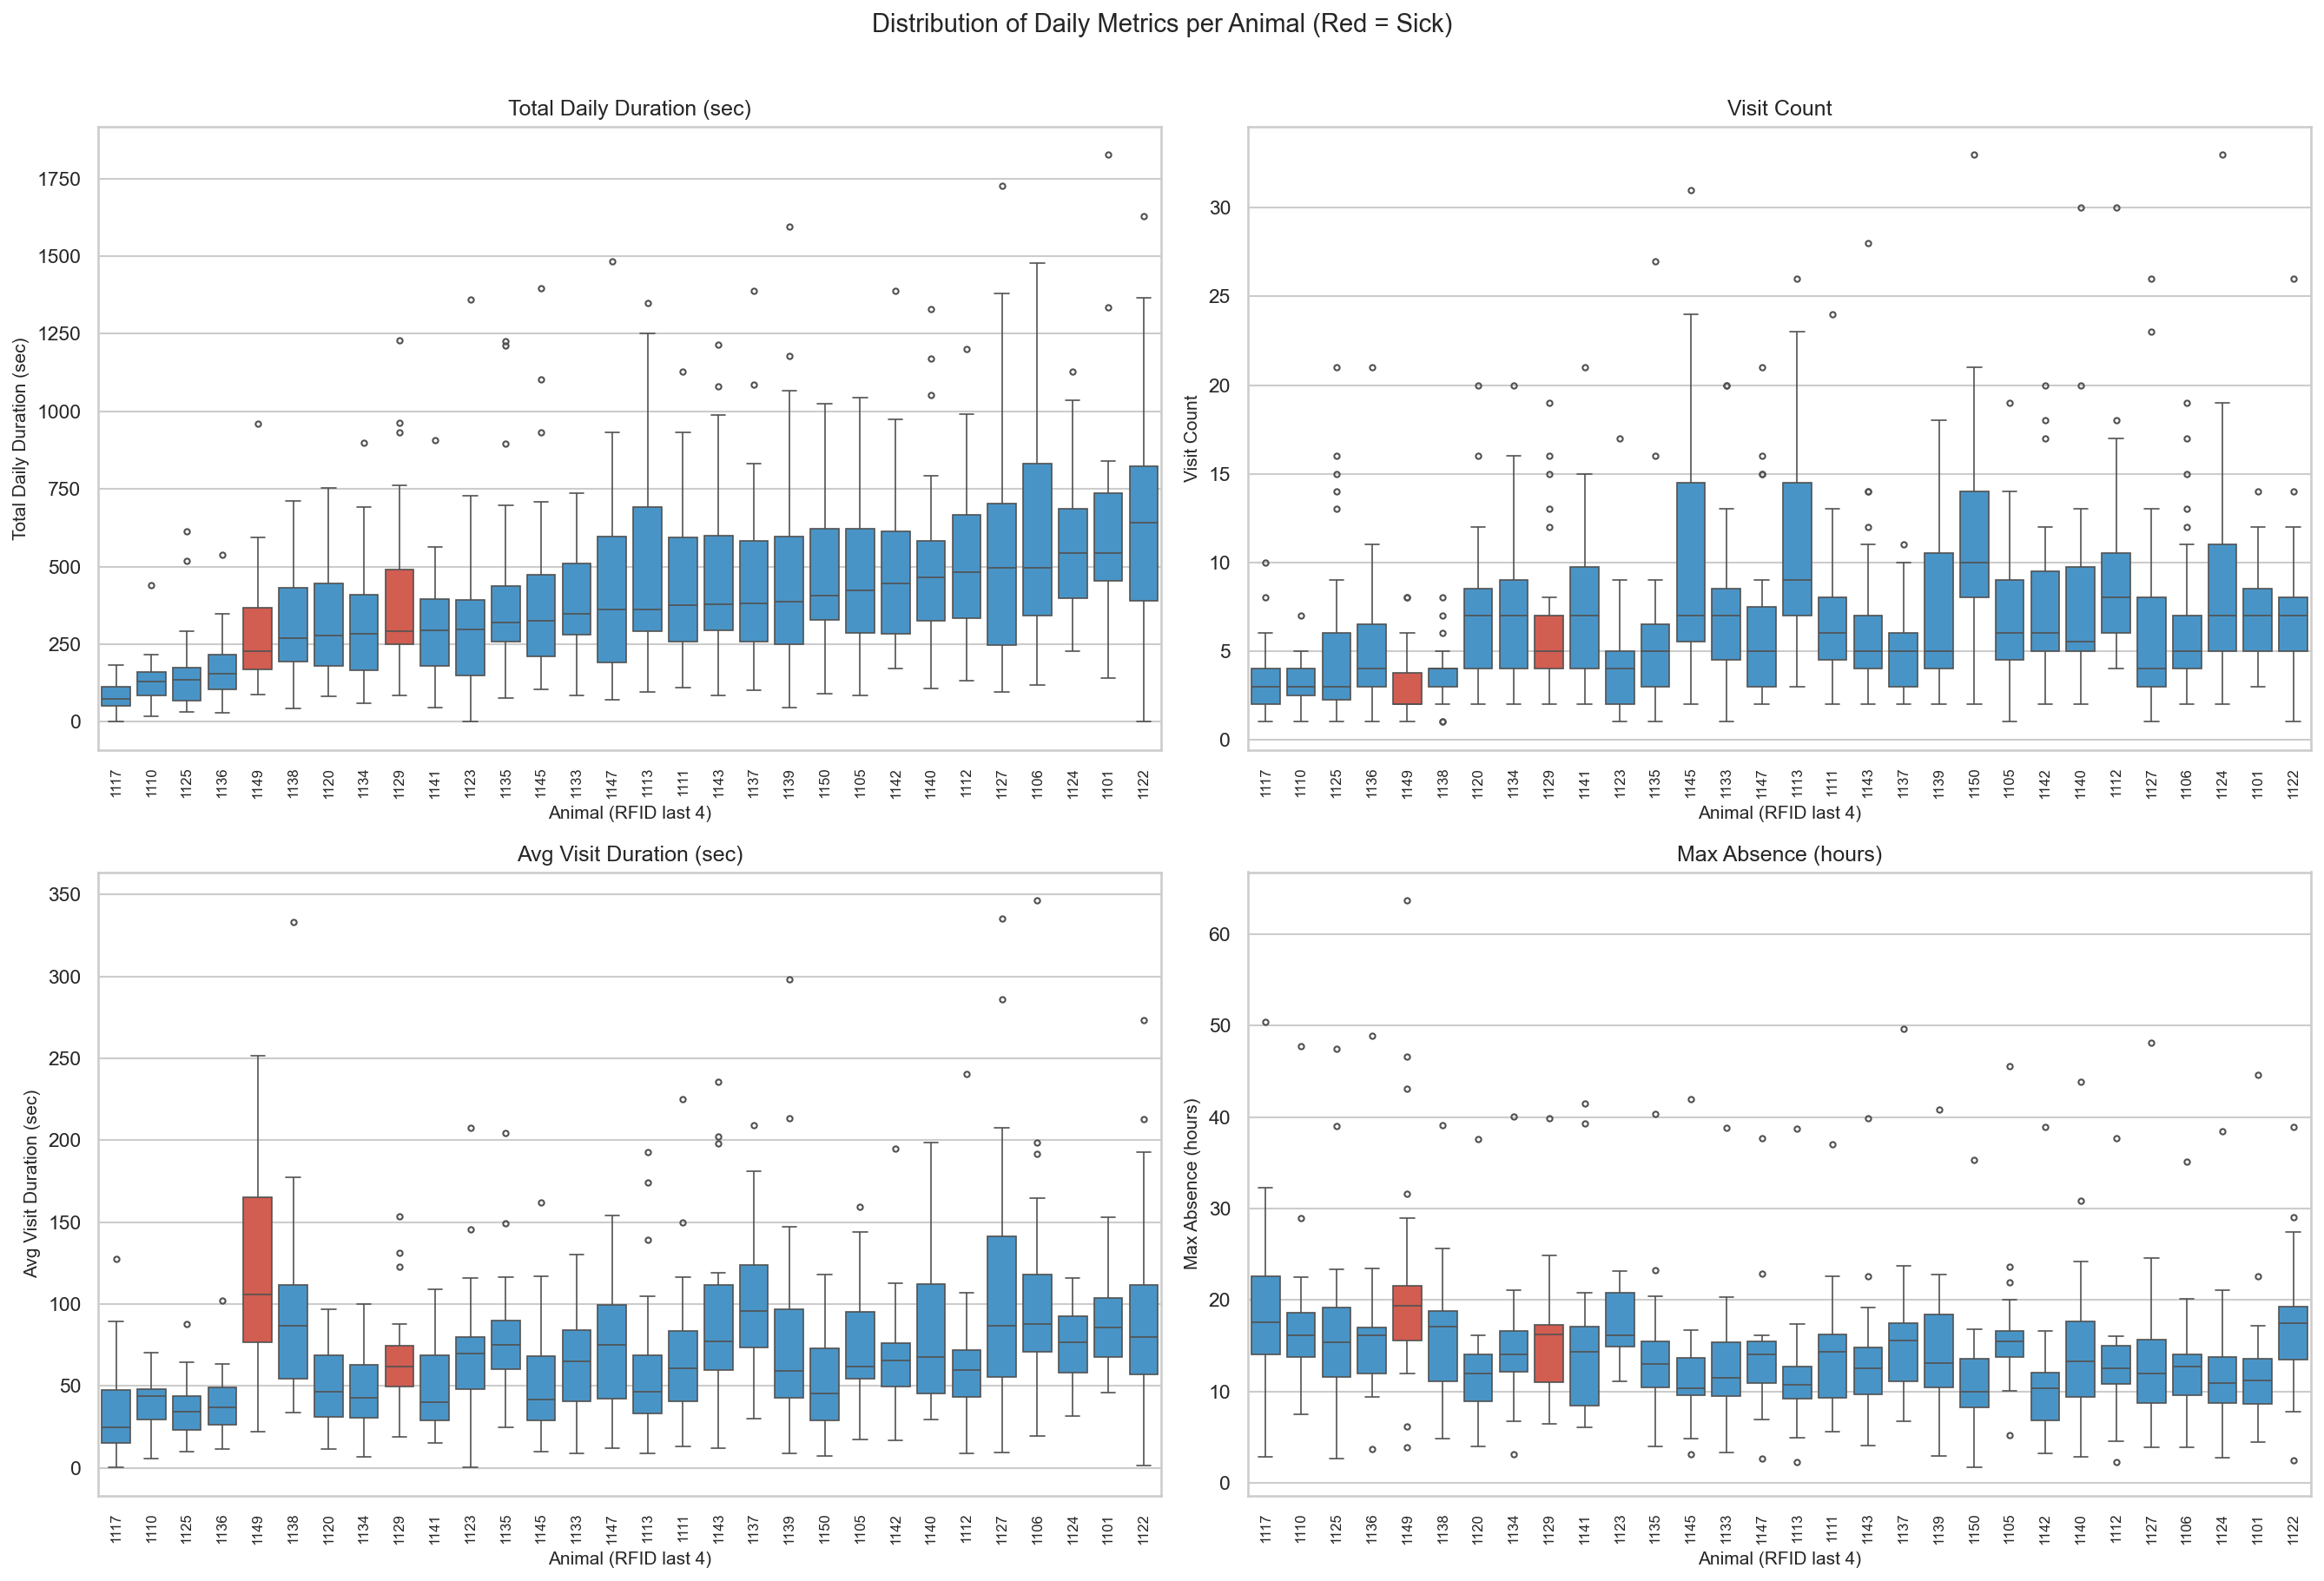

Saved: fig6_boxplots_per_animal.png


In [7]:
# Figure 6: Box plots per animal for each feature
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# Sort animals by median total_daily_duration for consistent ordering
animal_order = df_daily.groupby('tag_short')['total_daily_duration'].median().sort_values().index.tolist()

for i, (col, label) in enumerate(zip(feature_cols, feature_labels)):
    ax = axes[i]
    
    # Color sick animals differently
    palette = {}
    for tag in animal_order:
        if tag in [str(t) for t in sick_with_data]:
            palette[tag] = '#e74c3c'
        else:
            palette[tag] = '#3498db'
    
    sns.boxplot(data=df_daily, x='tag_short', y=col, order=animal_order, 
                palette=palette, ax=ax, fliersize=3, linewidth=0.8)
    
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Animal (RFID last 4)', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.tick_params(axis='x', rotation=90, labelsize=8)

fig.suptitle('Distribution of Daily Metrics per Animal (Red = Sick)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig6_boxplots_per_animal.png'), bbox_inches='tight')
plt.show()
print("Saved: fig6_boxplots_per_animal.png")

## Figure 7: Feature Correlation Matrix

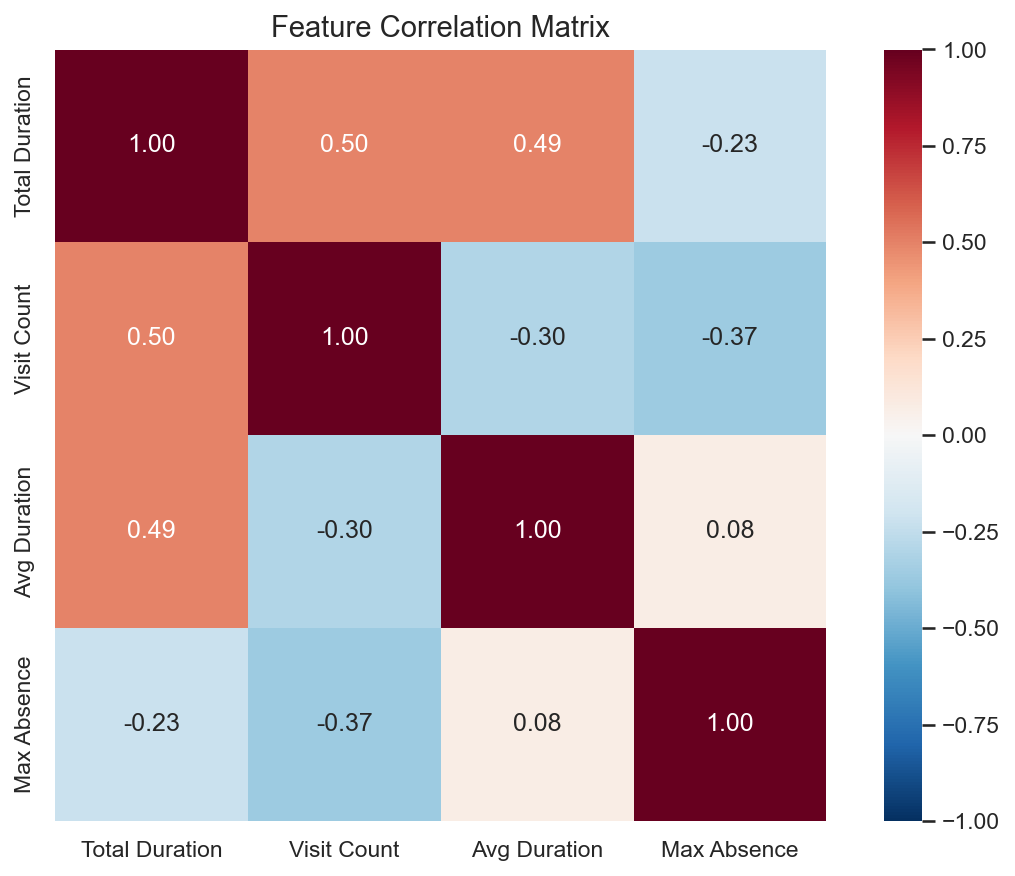

Saved: fig7_correlation_matrix.png


In [8]:
# Figure 7: Correlation matrix of the 4 features
fig, ax = plt.subplots(figsize=(8, 6))

corr = df_daily[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, ax=ax, vmin=-1, vmax=1,
            xticklabels=['Total Duration', 'Visit Count', 'Avg Duration', 'Max Absence'],
            yticklabels=['Total Duration', 'Visit Count', 'Avg Duration', 'Max Absence'])

ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig7_correlation_matrix.png'), bbox_inches='tight')
plt.show()
print("Saved: fig7_correlation_matrix.png")